# Business Sales Performance Analytics

## Exploratory Data Analysis (EDA)

### Objective

The objective of this analysis is to identify sales trends, product performance, category performance, regional performance, and profitability patterns to support business decision-making.

## 1. Load cleaned Dataset

In [34]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns",None)

df=pd.read_csv("../outputs/cleaned_superstore.csv",parse_dates=["Order Date", "Ship Date"] )


In [36]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Quarter,Shipping Days,Profit Margin %
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,November,4,3,16.00
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,November,4,3,30.00
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,June,2,4,47.00
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,October,4,7,-40.00
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,October,4,7,11.25


## 2. Dataset Overview

In [38]:
print("Dataset Shape:",df.shape)
df.info()

Dataset Shape: (9994, 26)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Row ID           9994 non-null   int64         
 1   Order ID         9994 non-null   object        
 2   Order Date       9994 non-null   datetime64[ns]
 3   Ship Date        9994 non-null   datetime64[ns]
 4   Ship Mode        9994 non-null   object        
 5   Customer ID      9994 non-null   object        
 6   Customer Name    9994 non-null   object        
 7   Segment          9994 non-null   object        
 8   Country          9994 non-null   object        
 9   City             9994 non-null   object        
 10  State            9994 non-null   object        
 11  Postal Code      9994 non-null   int64         
 12  Region           9994 non-null   object        
 13  Product ID       9994 non-null   object        
 14  Category      

## Dataset Overview Findings

- Dataset contains 9,994 records and 26 columns.
- No missing values are present.
- No duplicate records are present.
- Order Date and Ship Date are correctly stored as datetime data types.
- Dataset is ready for exploratory analysis.

## 3. Revenue Analysis

In [43]:
total_sales = df["Sales"].sum()
print("Total Sales Revenue: ${:,.2f}".format(total_sales))

Total Sales Revenue: $2,297,200.86


In [49]:
sales_by_year = df.groupby("Order Year")["Sales"].sum()
sales_by_year

Order Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64

## Revenue Analysis Findings

### Total Revenue

The business generated a total sales revenue of $2.297 Million during the analysis period.

### Yearly Revenue Trend

Revenue increased significantly between 2014 and 2017, indicating consistent business growth.

| Year | Revenue |
|--------|---------:|
| 2014 | $484,247 |
| 2015 | $470,533 |
| 2016 | $609,206 |
| 2017 | $733,215 |

### Key Observation

- Revenue declined slightly in 2015 compared to 2014.
- Strong recovery occurred in 2016.
- 2017 recorded the highest revenue, representing the strongest business performance during the period.

### Business Implication

The company appears to have successfully expanded sales after 2015, suggesting improvements in product strategy, customer acquisition, or market reach.

### Recommendation

Continue investing in the strategies that contributed to growth between 2016 and 2017 while investigating factors responsible for the temporary decline in 2015.

## Yearly Revenue Trend Visualization

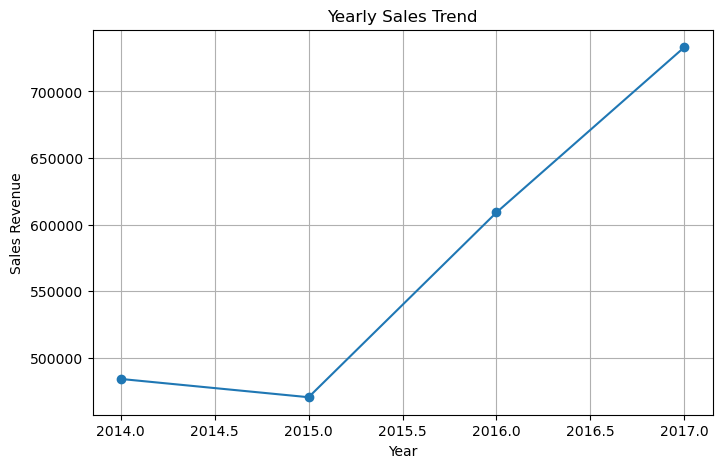

In [56]:
plt.figure(figsize=(8,5))
sales_by_year.plot(
    kind="line", marker="o" )

plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales Revenue")

plt.grid(True)
plt.show()

## Year-over-Year Growth Analysis

In [59]:
growth_rate = sales_by_year.pct_change() * 100 
growth_rate

Order Year
2014          NaN
2015    -2.832227
2016    29.471521
2017    20.355962
Name: Sales, dtype: float64

## Year-over-Year Growth Rate Visualization

Visualizing annual growth rates helps identify periods of decline, recovery, and business expansion.

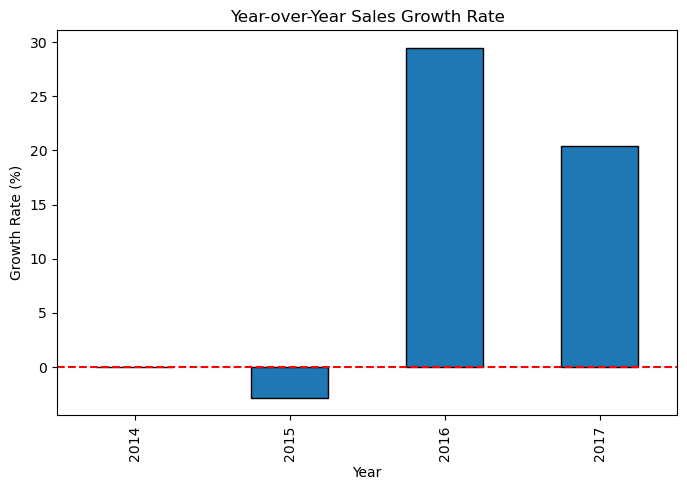

In [70]:
plt.figure(figsize=(8,5))
growth_rate.plot(
    kind = "bar",
    edgecolor="black" 
)
plt.title("Year-over-Year Sales Growth Rate")
plt.xlabel("Year")
plt.ylabel("Growth Rate (%)")

plt.axhline(y=0, color="red", linestyle= "--")

plt.show()

### Key Findings

| Year | Growth Rate |
|------|-------------|
| 2015 | -2.83% |
| 2016 | +29.47% |
| 2017 | +20.36% |

### Observations

- Sales declined slightly in 2015.
- The business recovered strongly in 2016 with nearly 30% growth.
- Growth continued in 2017, making it the highest revenue year.

### Business Insight

The company demonstrated strong recovery and expansion after 2015. The sustained growth during 2016–2017 suggests successful business strategies and increasing market demand.

### Recommendation

Analyze the factors that contributed to the growth achieved in 2016 and 2017 and replicate those strategies across future business operations.

## 4. Monthly Revenue Trend Analysis

In [65]:
monthly_sales = (df.groupby("Order Month")["Sales"].sum())
monthly_sales

Order Month
April        137762.1286
August       159044.0630
December     325293.5035
February      59751.2514
January       94924.8356
July         147238.0970
June         152718.6793
March        205005.4888
May          155028.8117
November     352461.0710
October      200322.9847
September    307649.9457
Name: Sales, dtype: float64

In [74]:
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"
]
monthly_sales=monthly_sales.reindex(month_order)
monthly_sales

Order Month
January       94924.8356
February      59751.2514
March        205005.4888
April        137762.1286
May          155028.8117
June         152718.6793
July         147238.0970
August       159044.0630
September    307649.9457
October      200322.9847
November     352461.0710
December     325293.5035
Name: Sales, dtype: float64

## Monthly Revenue Analysis

The monthly revenue analysis helps identify seasonal sales patterns and peak business periods throughout the year.

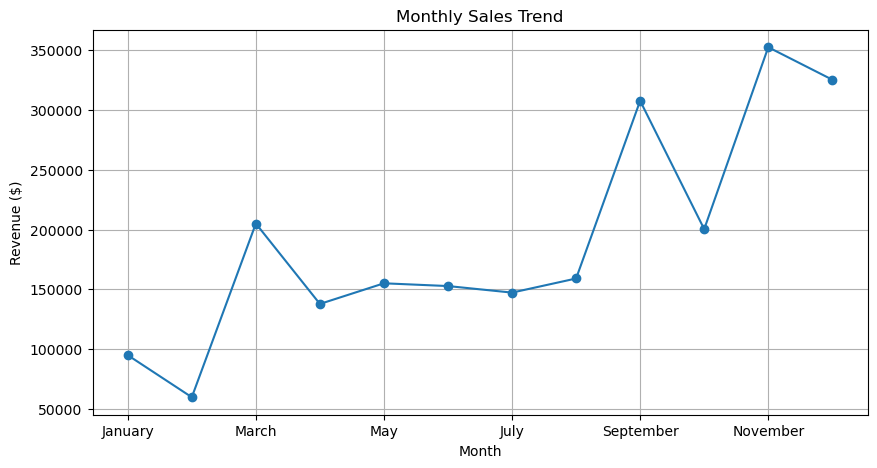

In [92]:
plt.figure(figsize=(10,5))
monthly_sales.plot(
    kind = "line",
    marker="o" 
)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")

plt.grid(True)

plt.show()

## Monthly Revenue Analysis Findings

### Key Observations

- February recorded the lowest sales revenue at approximately $59.8K.
- Revenue increased significantly in March, reaching approximately $205K.
- Sales remained relatively stable between April and August.
- A strong sales surge occurred during September, November, and December.
- November recorded the highest monthly revenue at approximately $352.5K.
- December remained strong with approximately $325.3K in revenue.

### Business Insights

- The business demonstrates clear seasonal sales patterns.
- Q4 (October–December) is the strongest revenue-generating period.
- The significant increase during November and December may be influenced by holiday shopping, seasonal promotions, and year-end purchasing behavior.
- February appears to be the weakest month and may require targeted marketing initiatives.

### Recommendations

1. Increase inventory levels before the Q4 sales season.
2. Allocate more marketing budget during September–December.
3. Introduce promotional campaigns during January and February to improve sales performance.
4. Analyze successful Q4 strategies and replicate them during lower-performing months.

## 5. Profit Analysis

Analyze overall profitability and identify which business categories contribute the most profit.

In [84]:
total_profit = df["Profit"].sum()

print("Total Profit: ${:,.2f}".format(total_profit))

Total Profit: $286,397.02


In [88]:
profit_by_category = (
    df.groupby("Category")["Profit"].sum().sort_values(ascending=False)
)
profit_by_category

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

## Profit Analysis Findings

### Total Profit

The business generated a total profit of $286,397.02 during the analysis period.

### Profit by Category

| Category | Profit |
|----------|---------:|
| Technology | $145,454.95 |
| Office Supplies | $122,490.80 |
| Furniture | $18,451.27 |

### Key Observations

- Technology is the most profitable category.
- Office Supplies contributes significant profit despite typically having lower-priced products.
- Furniture generates considerably lower profit compared to the other categories.

### Business Insight

High sales do not always translate into high profit. Although Furniture may contribute substantial revenue, its profitability is significantly lower than Technology and Office Supplies.

### Recommendation

- Continue investing in Technology products due to their strong profitability.
- Maintain Office Supplies as a stable profit-generating category.
- Investigate Furniture pricing, discount policies, and operational costs to improve profitability.

## Profit Distribution by Category

# plt.figure(figsize=(8,5))
profit_by_category.plot(
    kind = "bar",
    edgecolor="black" 
)
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit ($)")

plt.show()

## Category-wise Sales Analysis

Compare category sales with category profit to evaluate category efficiency and profitability.

In [99]:
category_sales = (
    df.groupby("Category")["Sales"].sum().sort_values(ascending=False))
category_sales

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

## Category Sales vs Profit Findings

### Sales Performance

| Category | Sales |
|----------|---------:|
| Technology | $836,154 |
| Furniture | $741,999 |
| Office Supplies | $719,047 |

### Key Observations

- Technology leads in both sales and profit.
- Furniture generates strong sales revenue but contributes very little profit.
- Office Supplies demonstrates strong profitability despite lower sales than Furniture.

### Business Insight

The Furniture category appears inefficient from a profitability perspective. Although it contributes significantly to total revenue, its profit contribution is disproportionately low.

### Recommendation

Conduct a detailed investigation into Furniture discounts, pricing strategy, and operational costs to identify factors reducing profitability.

## Category Sales Comparison

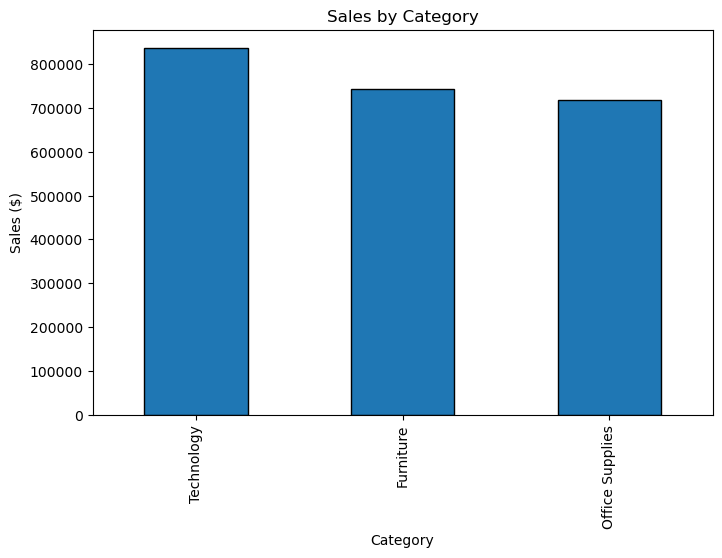

In [103]:
plt.figure(figsize=(8,5))
category_sales.plot(
    kind = "bar",
    edgecolor="black" 
)
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales ($)")

plt.show()

## 6. Regional Performance Analysis

Analyze sales and profitability across different regions to identify high-performing and underperforming markets.

In [106]:
regional_sales = (
    df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
)
regional_sales

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

In [110]:
regional_profit = (
    df.groupby("Region")["Profit"].sum().sort_values(ascending=False)
)
regional_profit

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64

## Regional Performance Findings

### Sales Performance

| Region | Sales |
|---------|---------:|
| West | $725,458 |
| East | $678,781 |
| Central | $501,240 |
| South | $391,722 |

### Profit Performance

| Region | Profit |
|---------|---------:|
| West | $108,418 |
| East | $91,523 |
| South | $46,749 |
| Central | $39,706 |

### Key Observations

- West is the highest-performing region in both sales and profit.
- East also demonstrates strong business performance.
- Central generates relatively high sales but low profit.
- South produces lower sales but better profitability than Central.

### Business Insight

The Central region may be facing profitability challenges despite generating substantial revenue. This indicates a need for deeper investigation into pricing, discounts, and product performance.

### Recommendation

- Replicate successful strategies from the West region.
- Investigate factors reducing profitability in the Central region.
- Expand marketing efforts in high-performing regions.

## Regional Sales Comparison

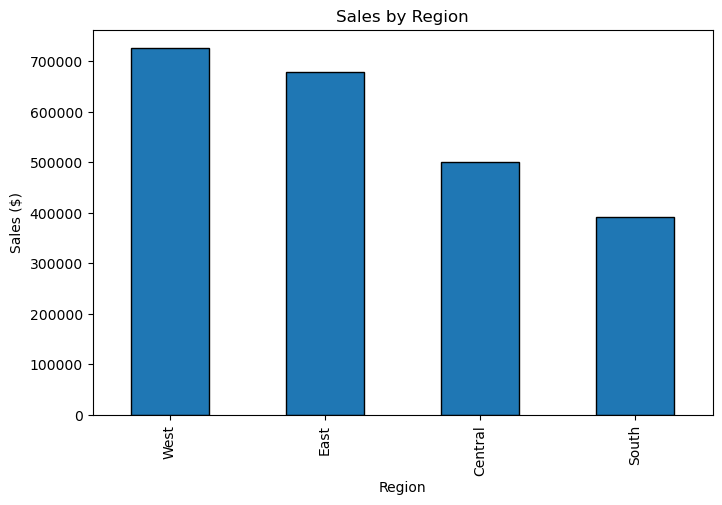

In [117]:
plt.figure(figsize=(8,5))
regional_sales.plot(
    kind = "bar",
    edgecolor="black" 
)
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales ($)")

plt.show()

## Regional Profit Comparison

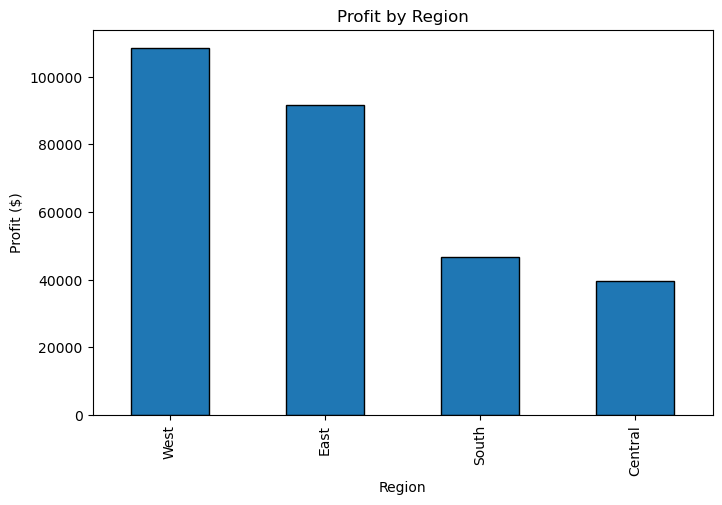

In [119]:
plt.figure(figsize=(8,5))
regional_profit.plot(
    kind = "bar",
    edgecolor="black" 
)
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit ($)")

plt.show()

## 7. Product Performance Analysis

Identify the highest-performing products based on sales and profitability.

In [138]:
top_products_sales = (
    df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)
)
top_products_sales

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

In [140]:
top_products_profit = (
    df.groupby("Product Name")["Profit"].sum().sort_values(ascending=False).head(10)
)
top_products_profit

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64

## Product Performance Findings

### Key Observations

- Canon imageCLASS 2200 Advanced Copier is the highest-performing product in both sales and profit.
- Several products consistently appear among the top contributors to both revenue and profitability.
- Some products generate high sales revenue but do not appear among the most profitable products, indicating lower profit margins.

### Business Insight

Products that contribute strongly to both sales and profit should be prioritized in inventory planning, promotions, and marketing campaigns.

### Recommendation

1. Increase focus on high-profit products.
2. Investigate high-sales but low-profit products.
3. Optimize pricing and discount strategies for underperforming products.

## Top 10 Products by Sales

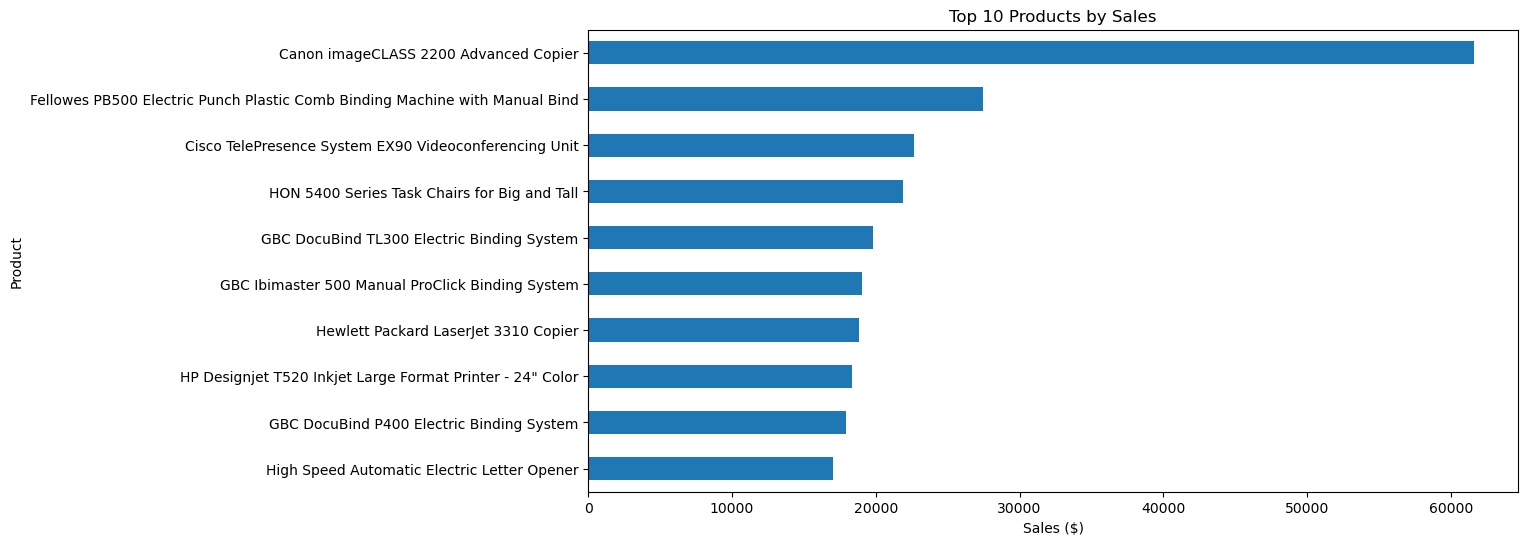

In [142]:
plt.figure(figsize=(12,6))

top_products_sales.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales ($)")
plt.ylabel("Product")

plt.show()

## Top 10 Products by Profit

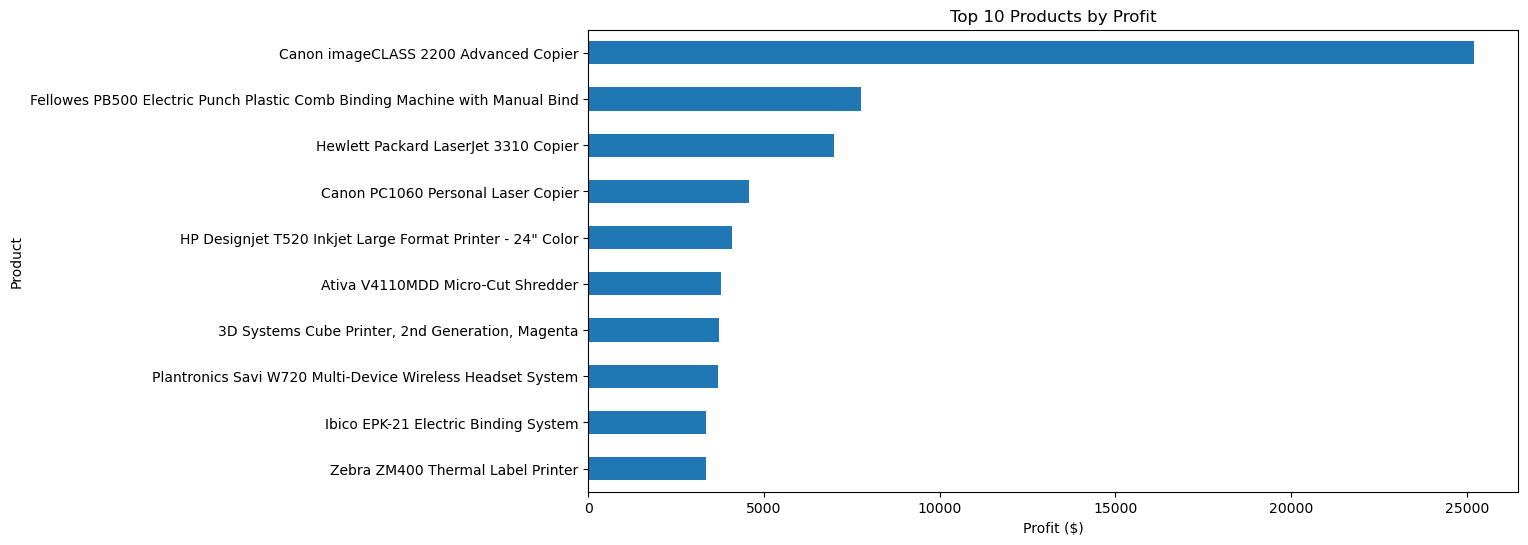

In [147]:
plt.figure(figsize=(12,6))

top_products_profit.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Products by Profit")
plt.xlabel("Profit ($)")
plt.ylabel("Product")

plt.show()

## 8. Discount Impact Analysis

Analyze the relationship between discounts and profitability to understand whether discounting strategies affect business performance.

In [150]:
discount_profit = (
    df.groupby("Discount")["Profit"].mean().sort_values() 
)
discount_profit

Discount
0.50   -310.703456
0.45   -226.646464
0.40   -111.927429
0.80   -101.796797
0.70    -95.874060
0.32    -88.560656
0.30    -45.679636
0.60    -43.077212
0.20     24.702572
0.15     27.288298
0.00     66.900292
0.10     96.055074
Name: Profit, dtype: float64

## Discount Impact Findings

### Key Observations

- Higher discounts are strongly associated with lower profitability.
- Discounts of 30% or more generally result in negative average profit.
- Products sold without discounts generate healthy profits.
- A 10% discount still maintains strong profitability.

### Business Insight

Aggressive discounting appears to be reducing business profitability. While discounts may increase sales volume, excessive discounts are causing financial losses on many transactions.

### Recommendation

1. Limit discounts above 20% whenever possible.
2. Review pricing strategies for heavily discounted products.
3. Focus on value-based promotions instead of deep discounts.
4. Investigate categories frequently sold with high discounts.

## Impact of Discounts on Profitability

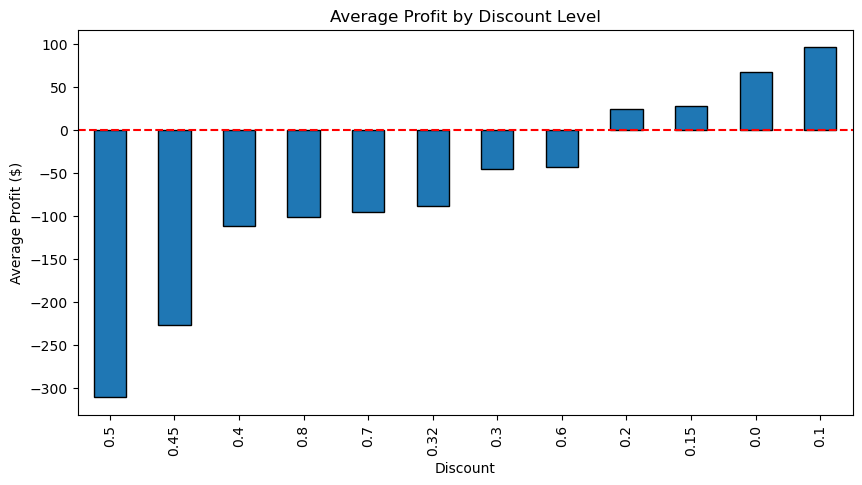

In [158]:
plt.figure(figsize=(10,5))

discount_profit.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Average Profit by Discount Level")
plt.xlabel("Discount")
plt.ylabel("Average Profit ($)")

plt.axhline(y=0, color="red", linestyle="--")

plt.show()

## 9. Key Findings Summary

### Key Findings

1. The business generated $2.297 million in total sales revenue.

2. Revenue grew significantly between 2016 and 2017, indicating strong business expansion.

3. Q4 (October–December) is the strongest sales period, with November generating the highest monthly revenue.

4. Technology is the most profitable category and contributes over half of total business profit.

5. Furniture generates high sales but very low profit, indicating profitability challenges.

6. The West region is the strongest performer in both sales and profit.

7. Canon imageCLASS 2200 Advanced Copier is the highest-performing product by both sales and profit.

8. Discounts above 30% are strongly associated with negative profitability.

### Strategic Recommendations

1. Increase investment in Technology products.

2. Review pricing and discount strategies within the Furniture category.

3. Replicate successful sales strategies from the West region.

4. Prepare inventory and marketing campaigns for the Q4 sales season.

5. Reduce excessive discounting to improve overall profitability.

## 10. Export Analysis Outputs

Export key analytical results for dashboard development and reporting.

In [162]:
monthly_sales.to_csv("../outputs/monthly_sales.csv")
category_sales.to_csv("../outputs/category_sales.csv")
regional_sales.to_csv("../outputs/regional_sales.csv")
top_products_sales.to_csv("../outputs/top_products.csv")
print("Analysis outputs exported successfully.")

Analysis outputs exported successfully.


# Exploratory Data Analysis Conclusion

## Overview

The analysis examined sales performance, profitability, product performance, category performance, regional performance, and discount impact using historical business sales data.

## Major Findings

### Revenue Performance

- Total Sales Revenue: $2.297 Million
- Highest Revenue Year: 2017
- Strong revenue growth observed during 2016 and 2017.

### Seasonal Trends

- November generated the highest monthly sales revenue.
- Q4 (October–December) is the strongest sales period.
- February recorded the lowest monthly revenue.

### Category Performance

- Technology is the most profitable category.
- Office Supplies contributes strong profits.
- Furniture generates high sales but low profit.

### Regional Performance

- West region is the highest-performing region in both sales and profit.
- East region is the second strongest market.
- Central region shows profitability challenges despite strong sales.

### Product Performance

- Canon imageCLASS 2200 Advanced Copier is the top-performing product by both sales and profit.

### Discount Impact

- Discounts above 30% are strongly associated with negative profitability.
- Excessive discounting reduces business profit significantly.

## Business Recommendations

1. Increase investment in Technology products.
2. Optimize pricing strategies for Furniture products.
3. Replicate successful strategies from the West region.
4. Prepare inventory and marketing campaigns for Q4 demand.
5. Reduce excessive discounting to improve profitability.

## Next Step

Proceed to KPI Analysis and Dashboard Development.